None


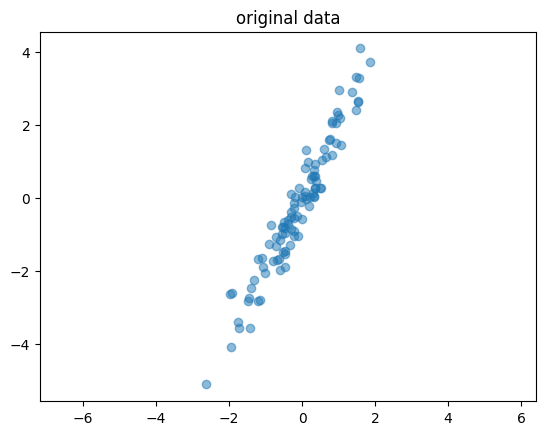

(100, 2)


In [2]:
import numpy as np
import matplotlib.pyplot as plt

print(np.random.seed(42))
x=np.random.randn(100)
y=2*x + np.random.randn(100)*0.5
data = np.column_stack([x,y])

plt.scatter(data[:,0],data[:,1],alpha=0.5)
plt.title('original data')
plt.axis('equal')
plt.show()
print(data.shape)


In [19]:
mean=np.mean(data,axis=0)
centered = data-mean
cov_matrix = np.cov(centered.T)
print("covariance matrix:")
print(cov_matrix)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("\neigenvalues:", eigenvalues)
print("eigenvectors:\n", eigenvectors)

covariance matrix:
[[0.82476989 1.59046269]
 [1.59046269 3.29014231]]

eigenvalues: [0.04522181 4.0696904 ]
eigenvectors:
 [[-0.89794091 -0.44011603]
 [ 0.44011603 -0.89794091]]


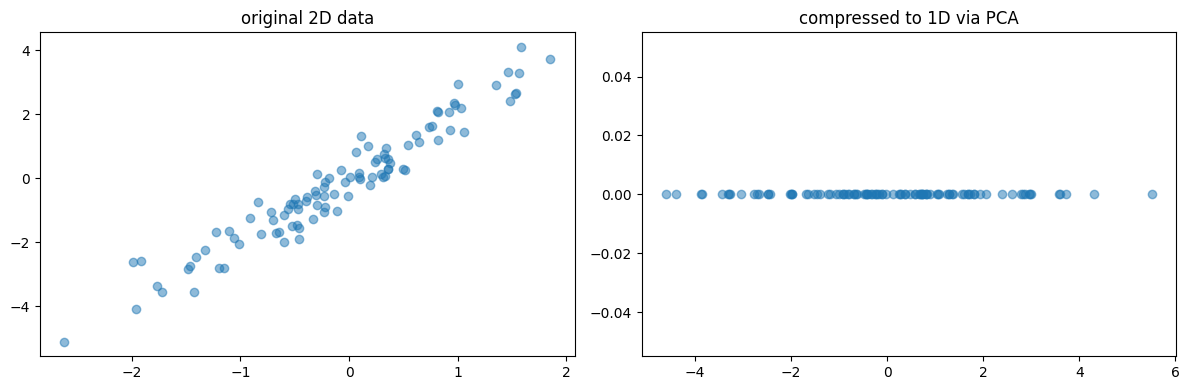

In [20]:
# sort eigenvectors by eigenvalue — largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

# project data onto first eigenvector only
pca_1d = centered @ eigenvectors[:, 0]

# plot original vs compressed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(data[:, 0], data[:, 1], alpha=0.5)
axes[0].set_title('original 2D data')

axes[1].scatter(pca_1d, np.zeros_like(pca_1d), alpha=0.5)
axes[1].set_title('compressed to 1D via PCA')

plt.tight_layout()
plt.show()

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
sklearn_result = pca.fit_transform(centered)

print("our PCA result (first 5):")
print(pca_1d[:5])

print("\nsklearn PCA result (first 5):")
print(sklearn_result[:5].flatten())

print("\nvariance explained:", pca.explained_variance_ratio_)

our PCA result (first 5):
[-0.69737862  0.27582951 -1.51654798 -3.26747919  0.37379247]

sklearn PCA result (first 5):
[ 0.69737862 -0.27582951  1.51654798  3.26747919 -0.37379247]

variance explained: [0.98901026]
